# **📈 Projet : Prédiction de la valeur du VKOSPI**

Ce projet s'inscrit dans le cadre du cours de **Machine Learning** dispensé par Théo Lopès-Quintas à l'Université Paris Dauphine.

---

# **👥 Auteurs**
HUYEN Joëlle  
HUYEN Julie  
JIANG Qinming  
SARFATI Léonore  
ZAFIZARA-BENETRIX Nathan  

---

# **🎯 Objectif**
L'objectif est de prédire la valeur de l'indice de volatilité implicite coréen VKOSPI, en utilisant des algorithmes de Machine Learning vus en cours.
La métrique de référence sera la RSME.

---

# [**📊 Description du Dataset VKOSPI**](https://www.kaggle.com/datasets/ninetyninenewton/vkospi/data)

Le dataset représente les **données de marché** pour l'indice **VKOSPI**, l'équivalent coréen de l'indice de volatilité implicite **VIX** aux États-Unis. Chaque ligne du dataset correspond à un **jour de trading**, excluant les week-ends et les jours fériés. Les colonnes fournissent diverses informations sur les **transactions et les positions** des options et des futures sur l'indice **KOSPI200**, qui est l'actif sous-jacent du VKOSPI.

---

# **🗂️ Description des Colonnes**

| **Nom de la colonne**           | **Description**                                                                                |
|---------------------------------|:-----------------------------------------------------------------------------------------------|
| **`Date`**                      | La date du jour de trading.                                                                    |
| **`VKOSPI`**                    | La valeur de l'indice de volatilité implicite **VKOSPI** pour ce jour.                         |
| **`KOSPI200`**                  | La valeur de l'indice **KOSPI200** pour ce jour.                                               |
| **`Open_interest`**             | Le nombre total de **contrats d'options ouverts** (non réglés) pour ce jour.                   |
| **`For_KOSPI_Netbuying_Amount`**| Le **montant net acheté** par les étrangers pour l'indice **KOSPI200** *(Prix × Quantité)*.    |
| **`For_Future_Netbuying_Quantity`** | La **quantité nette achetée** par les étrangers pour les **futures** de **KOSPI200**.          |
| **`For_Call_Netbuying_Quantity`**   | La **quantité nette achetée** par les étrangers pour les **options d'achat (call)**.           |
| **`For_Put_Netbuying_Quantity`**    | La **quantité nette achetée** par les étrangers pour les **options de vente (put)**.           |
| **`Indiv_Future_Netbuying_Quantity`** | La **quantité nette achetée** par les **individus** pour les **futures**.                      |
| **`Indiv_Call_Netbuying_Quantity`**   | La **quantité nette achetée** par les **individus** pour les **options d'achat (call)**.       |
| **`Indiv_Put_Netbuying_Quantity`**    | La **quantité nette achetée** par les **individus** pour les **options de vente (put)**.       |
| **`PCRatio`**                  | Le **ratio Put-Call**, rapport entre le **volume des options put** et **call** *(Put/Call)*.   |
| **`Day_till_expiration`**      | Le **nombre de jours restants** jusqu'à la **date d'expiration** des options.                  |
| **`Day_of_a_week`**      | Le **jour de la semaine** correspondant à la **date de trading** (ex: Lundi, Mardi, etc.).                 |

---

## **📝 Notes supplémentaires :**
- Les données couvrent uniquement les jours de trading actifs.
- Le VKOSPI est un indicateur clé de la **volatilité implicite** du marché coréen.
- Les valeurs nettes d'achat pour les étrangers et les individus offrent un aperçu des stratégies de marché.

---

In [271]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge


## **Exploration et préparation des données**

Commençons sans plus attendre par importer les données et les observer !

In [272]:
df = pd.read_csv("options_KR.csv")
df.head()

,Date,VKOSPI,KOSPI200,Open_interest,For_KOSPI_Netbuying_Amount,For_Future_Netbuying_Quantity,For_Call_Netbuying_Quantity,For_Put_Netbuying_Quantity,Indiv_Future_Netbuying_Quantity,Indiv_Call_Netbuying_Quantity,Indiv_Put_Netbuying_Quantity,PCRatio,Day_till_expiration,Day_of_a_week
0,2009-06-02,33.45,180.90,4377777,4.940000e+11,-4953,-24646,6581,1228,-466,31336,0.94,7,Tue
1,2009-06-03,32.66,180.47,4562690,-8.997074e+10,47,-57128,46851,399,127709,-22259,0.93,6,Wed
2,2009-06-04,32.56,180.31,4827524,-1.090000e+11,-7666,-2000,48883,5744,262558,10367,0.87,5,Thu
3,2009-06-05,32.95,175.75,5022921,9.842024e+10,969,64792,27196,-1688,79789,113935,0.89,4,Fri
4,2009-06-08,30.41,177.77,5293996,4.329179e+10,5797,10995,23123,-5534,97154,146244,0.81,3,Mon


In [273]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2580 entries, 0 to 2579
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             2580 non-null   object 
 1   VKOSPI                           2580 non-null   float64
 2   KOSPI200                         2580 non-null   float64
 3   Open_interest                    2580 non-null   int64  
 4   For_KOSPI_Netbuying_Amount       2580 non-null   float64
 5   For_Future_Netbuying_Quantity    2580 non-null   int64  
 6   For_Call_Netbuying_Quantity      2580 non-null   int64  
 7   For_Put_Netbuying_Quantity       2580 non-null   int64  
 8   Indiv_Future_Netbuying_Quantity  2580 non-null   int64  
 9   Indiv_Call_Netbuying_Quantity    2580 non-null   int64  
 10  Indiv_Put_Netbuying_Quantity     2580 non-null   int64  
 11  PCRatio                          2580 non-null   float64
 12  Day_till_expiration 

⚠️ On constate d'ores et déjà que la colonne "Date" est mal typée. On va immédiatemment la remettre en forme pour ne pas avoir de mauvaises surprises par la suite.

In [274]:
df['Date'] = pd.to_datetime(df['Date'])

Ensuite, on souhaite avoir une vue plus statistique du dataset. On ne prendra pas en compte que les données numériques (on ignore les colonnes liées aux dates pour le moment).

In [275]:
df.describe()

,Date,VKOSPI,KOSPI200,Open_interest,For_KOSPI_Netbuying_Amount,For_Future_Netbuying_Quantity,For_Call_Netbuying_Quantity,For_Put_Netbuying_Quantity,Indiv_Future_Netbuying_Quantity,Indiv_Call_Netbuying_Quantity,Indiv_Put_Netbuying_Quantity,PCRatio,Day_till_expiration
count,2580,2580.000000,2580.000000,2.580000e+03,2.580000e+03,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000,2580.000000
mean,2014-08-09 04:11:43.255813888,16.744302,259.246508,2.303927e+06,2.889290e+10,10.226744,2727.117829,14117.202326,4.820930,16000.406589,6695.945736,0.954837,9.982946
min,2009-06-02 00:00:00,9.720000,174.320000,2.242960e+05,-1.310000e+12,-20745.000000,-174455.000000,-183760.000000,-11879.000000,-179929.000000,-151533.000000,0.280000,0.000000
25%,2011-12-25 06:00:00,13.087500,243.750000,1.013118e+06,-1.130000e+11,-2164.750000,-2863.250000,1836.000000,-1209.500000,-2574.000000,-13051.250000,0.850000,5.000000
50%,2014-08-04 12:00:00,15.305000,257.310000,1.879194e+06,2.221070e+10,31.000000,1780.000000,9257.500000,-13.000000,4984.000000,-2065.500000,0.950000,10.000000
75%,2017-03-17 18:00:00,18.772500,271.570000,3.236718e+06,1.670000e+11,2221.500000,7435.250000,23097.500000,1213.500000,17872.250000,9729.000000,1.050000,15.000000
max,2019-11-07 00:00:00,50.110000,338.830000,9.134484e+06,1.720000e+12,20265.000000,152445.000000,228939.000000,10325.000000,908263.000000,919563.000000,1.790000,26.000000
std,NaN,5.327865,29.034358,1.578398e+06,2.560887e+11,3953.221118,19549.308255,25202.453076,2126.388898,53037.030365,59832.131764,0.170583,6.293434


Commençons par analyser la variable cible de notre modèle : l'indice VKOSPI. On observe un écart important entre le troisième quartile (Q3) et la valeur maximale, ce qui indique une forte dispersion des données. Cette variabilité pourrait entraîner une grande variance dans les résultats lors de la validation croisée, impactant ainsi la stabilité des performances du modèle.

En examinant les colonnes suivantes :

For_Future_Netbuying_Quantity  
For_Call_Netbuying_Quantity  
For_Put_Netbuying_Quantity  
Indiv_Future_Netbuying_Quantity  
Indiv_Call_Netbuying_Quantity  
Indiv_Put_Netbuying_Quantity,  

on constate des écarts extrêmes entre le premier quartile (Q1) et le minimum, ainsi qu’entre le troisième quartile (Q3) et le maximum. Cela suggère la présence d'outliers dans ces variables. On va alors tenter de les mettre en évidence.

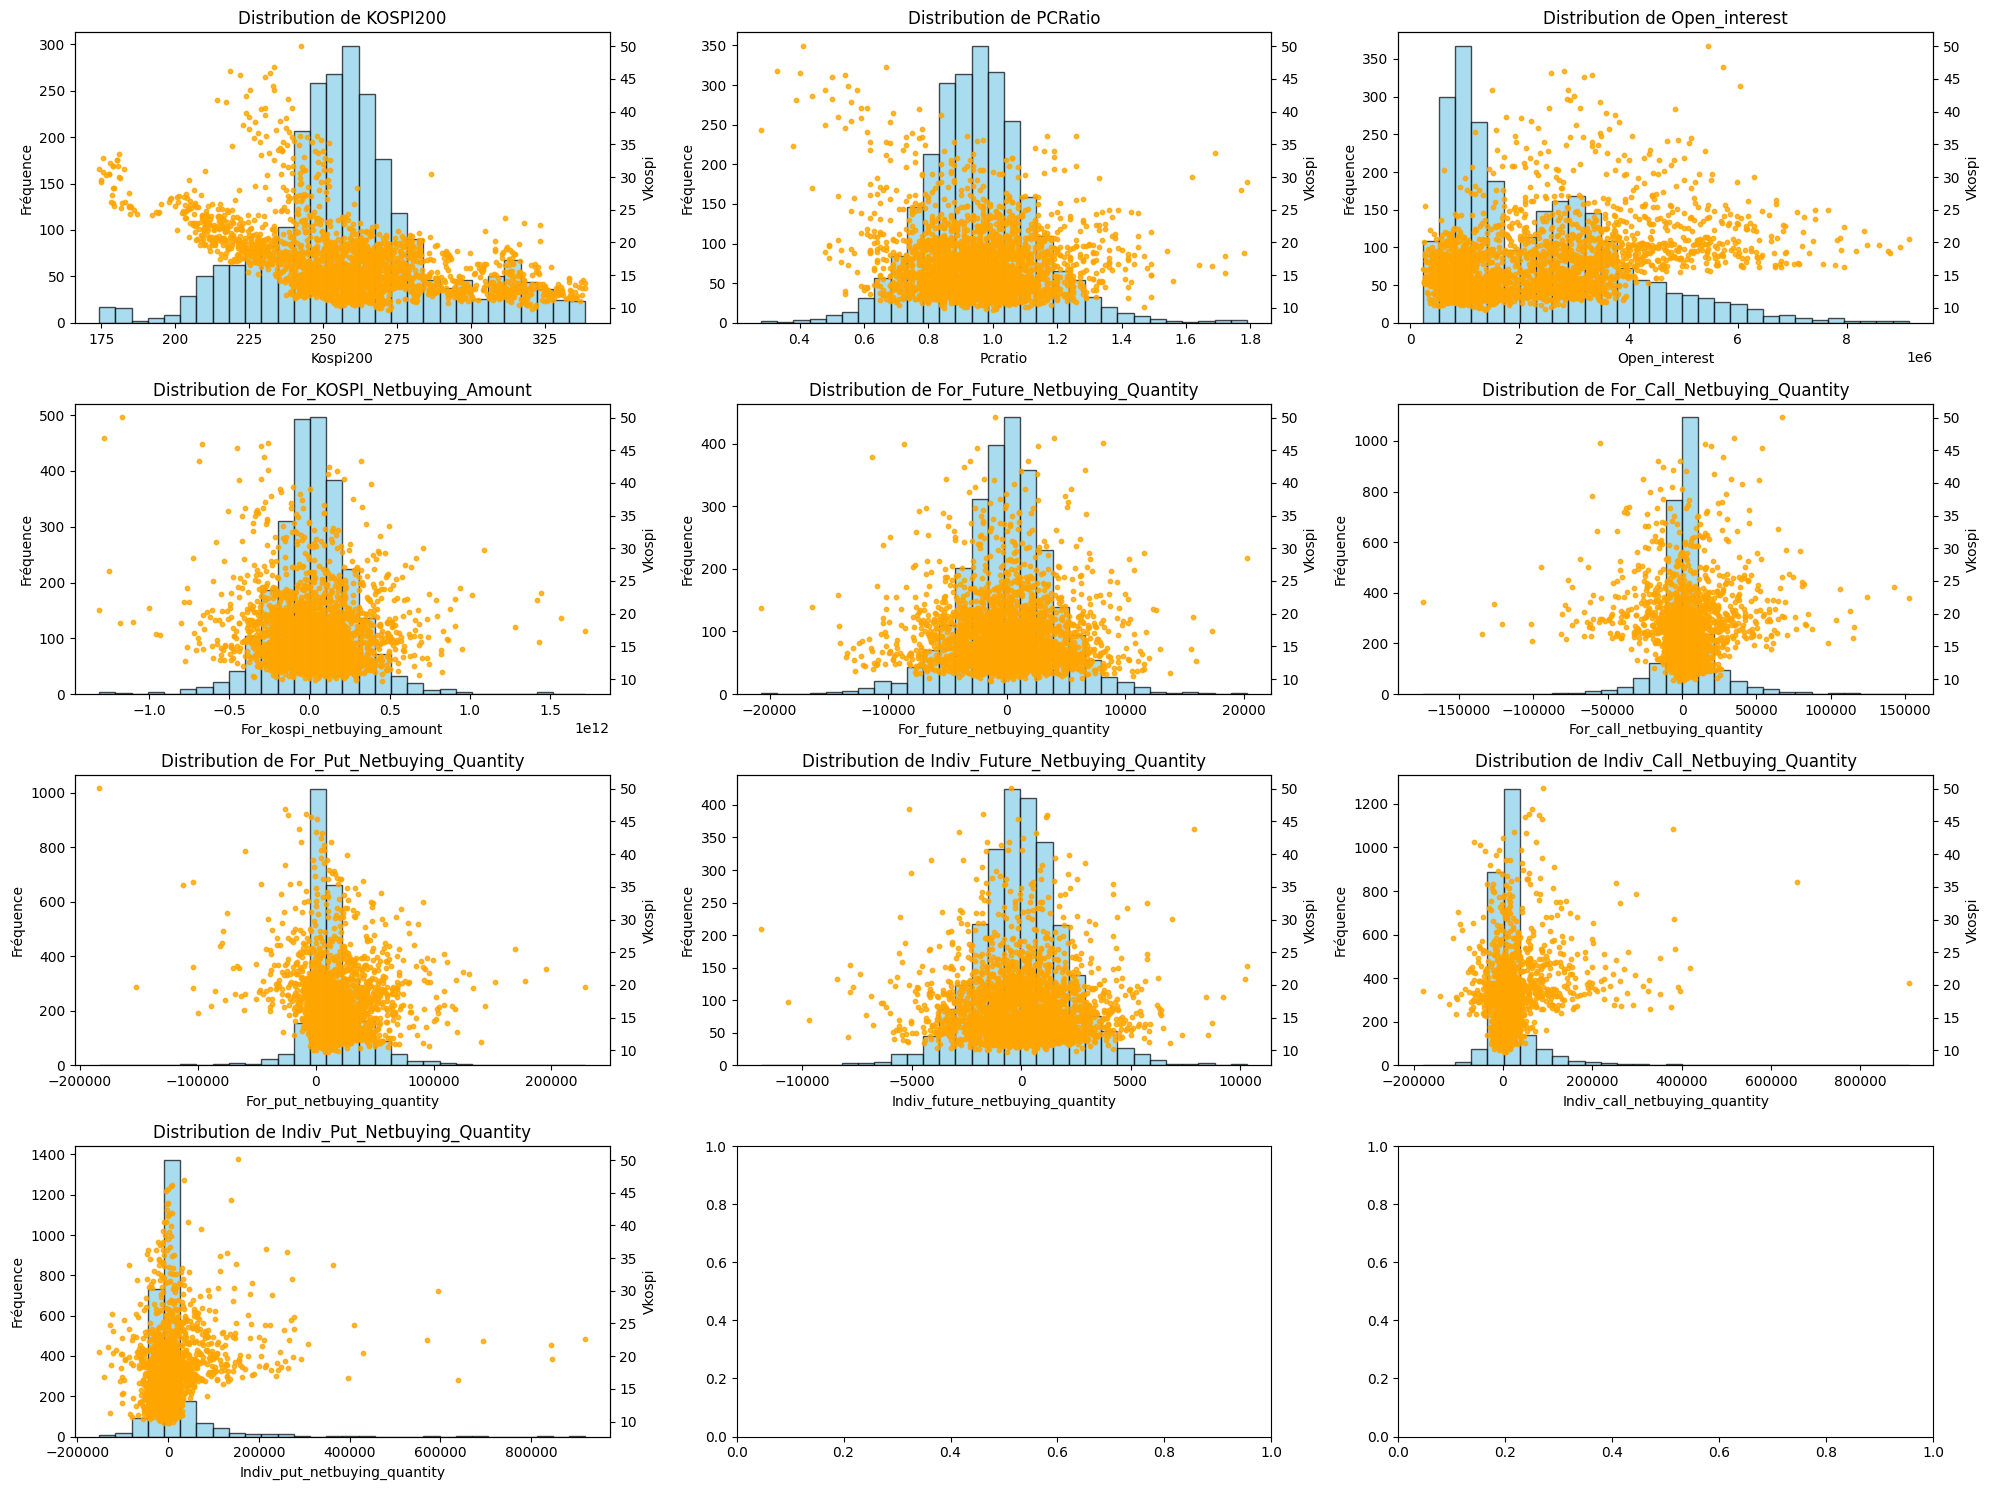

In [276]:
import matplotlib.pyplot as plt

def explore_columns_combined(df, columns, target_column, alpha=0.8, figsize=(20, 15)):
    n = len(columns)
    rows = (n + 2) // 3  # 3 colonnes par ligne

    fig, axes = plt.subplots(rows, 3, figsize=figsize)
    axes = axes.flatten()

    for i, column in enumerate(columns):
        # Histogramme avec axe principal
        axes[i].hist(df[column], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_xlabel(column.capitalize())
        axes[i].set_title(f"Distribution de {column}")
        axes[i].set_ylabel("Fréquence")  # Axe Y pour l'histogramme

        # Scatter plot avec un second axe Y
        ax2 = axes[i].twinx()
        ax2.scatter(df[column], df[target_column], alpha=alpha, color='orange', s=10)
        ax2.set_ylabel(target_column.capitalize())  # Axe Y pour VKOSPI

    plt.tight_layout()
    plt.show()

# Colonnes à explorer
columns_to_explore = [
    "KOSPI200", "PCRatio", "Open_interest", "For_KOSPI_Netbuying_Amount",
    "For_Future_Netbuying_Quantity", "For_Call_Netbuying_Quantity",
    "For_Put_Netbuying_Quantity", "Indiv_Future_Netbuying_Quantity",
    "Indiv_Call_Netbuying_Quantity", "Indiv_Put_Netbuying_Quantity",
]

explore_columns_combined(df, columns_to_explore, "VKOSPI")


A vue d'oeil, on remarque en effet certaines valeurs qui sortent du lot. De plus, ces observations ne sont pas dans la tendance que l'on observe avec la variable cible. Nous allons donc les supprimer car elles risquent d'empêcher notre modèle de bien apprendre !

In [277]:
print("Taille avant : %d" % df.shape[0])

df = df.loc[df["Indiv_Put_Netbuying_Quantity"] < 300000, ]
df = df.loc[df["Indiv_Call_Netbuying_Quantity"] < 300000, ]
df = df.loc[(df["Indiv_Future_Netbuying_Quantity"] > -8000) & (df["Indiv_Future_Netbuying_Quantity"] < 8000), ]
df = df.loc[(df["For_Put_Netbuying_Quantity"] > -100000) & (df["Indiv_Future_Netbuying_Quantity"] < 150000), ]
df = df.loc[(df["For_Call_Netbuying_Quantity"] > -100000) & (df["For_Call_Netbuying_Quantity"] < 100000), ]
df = df.loc[(df["For_KOSPI_Netbuying_Amount"] > -1), ]
# df = df.loc[(df["For_KOSPI_Netbuying_Amount"] > -1e12) & (df["For_KOSPI_Netbuying_Amount"] < 1.25e12), ]

print("Taille après : %d" % df.shape[0])

Taille avant : 2580
Taille après : 1387


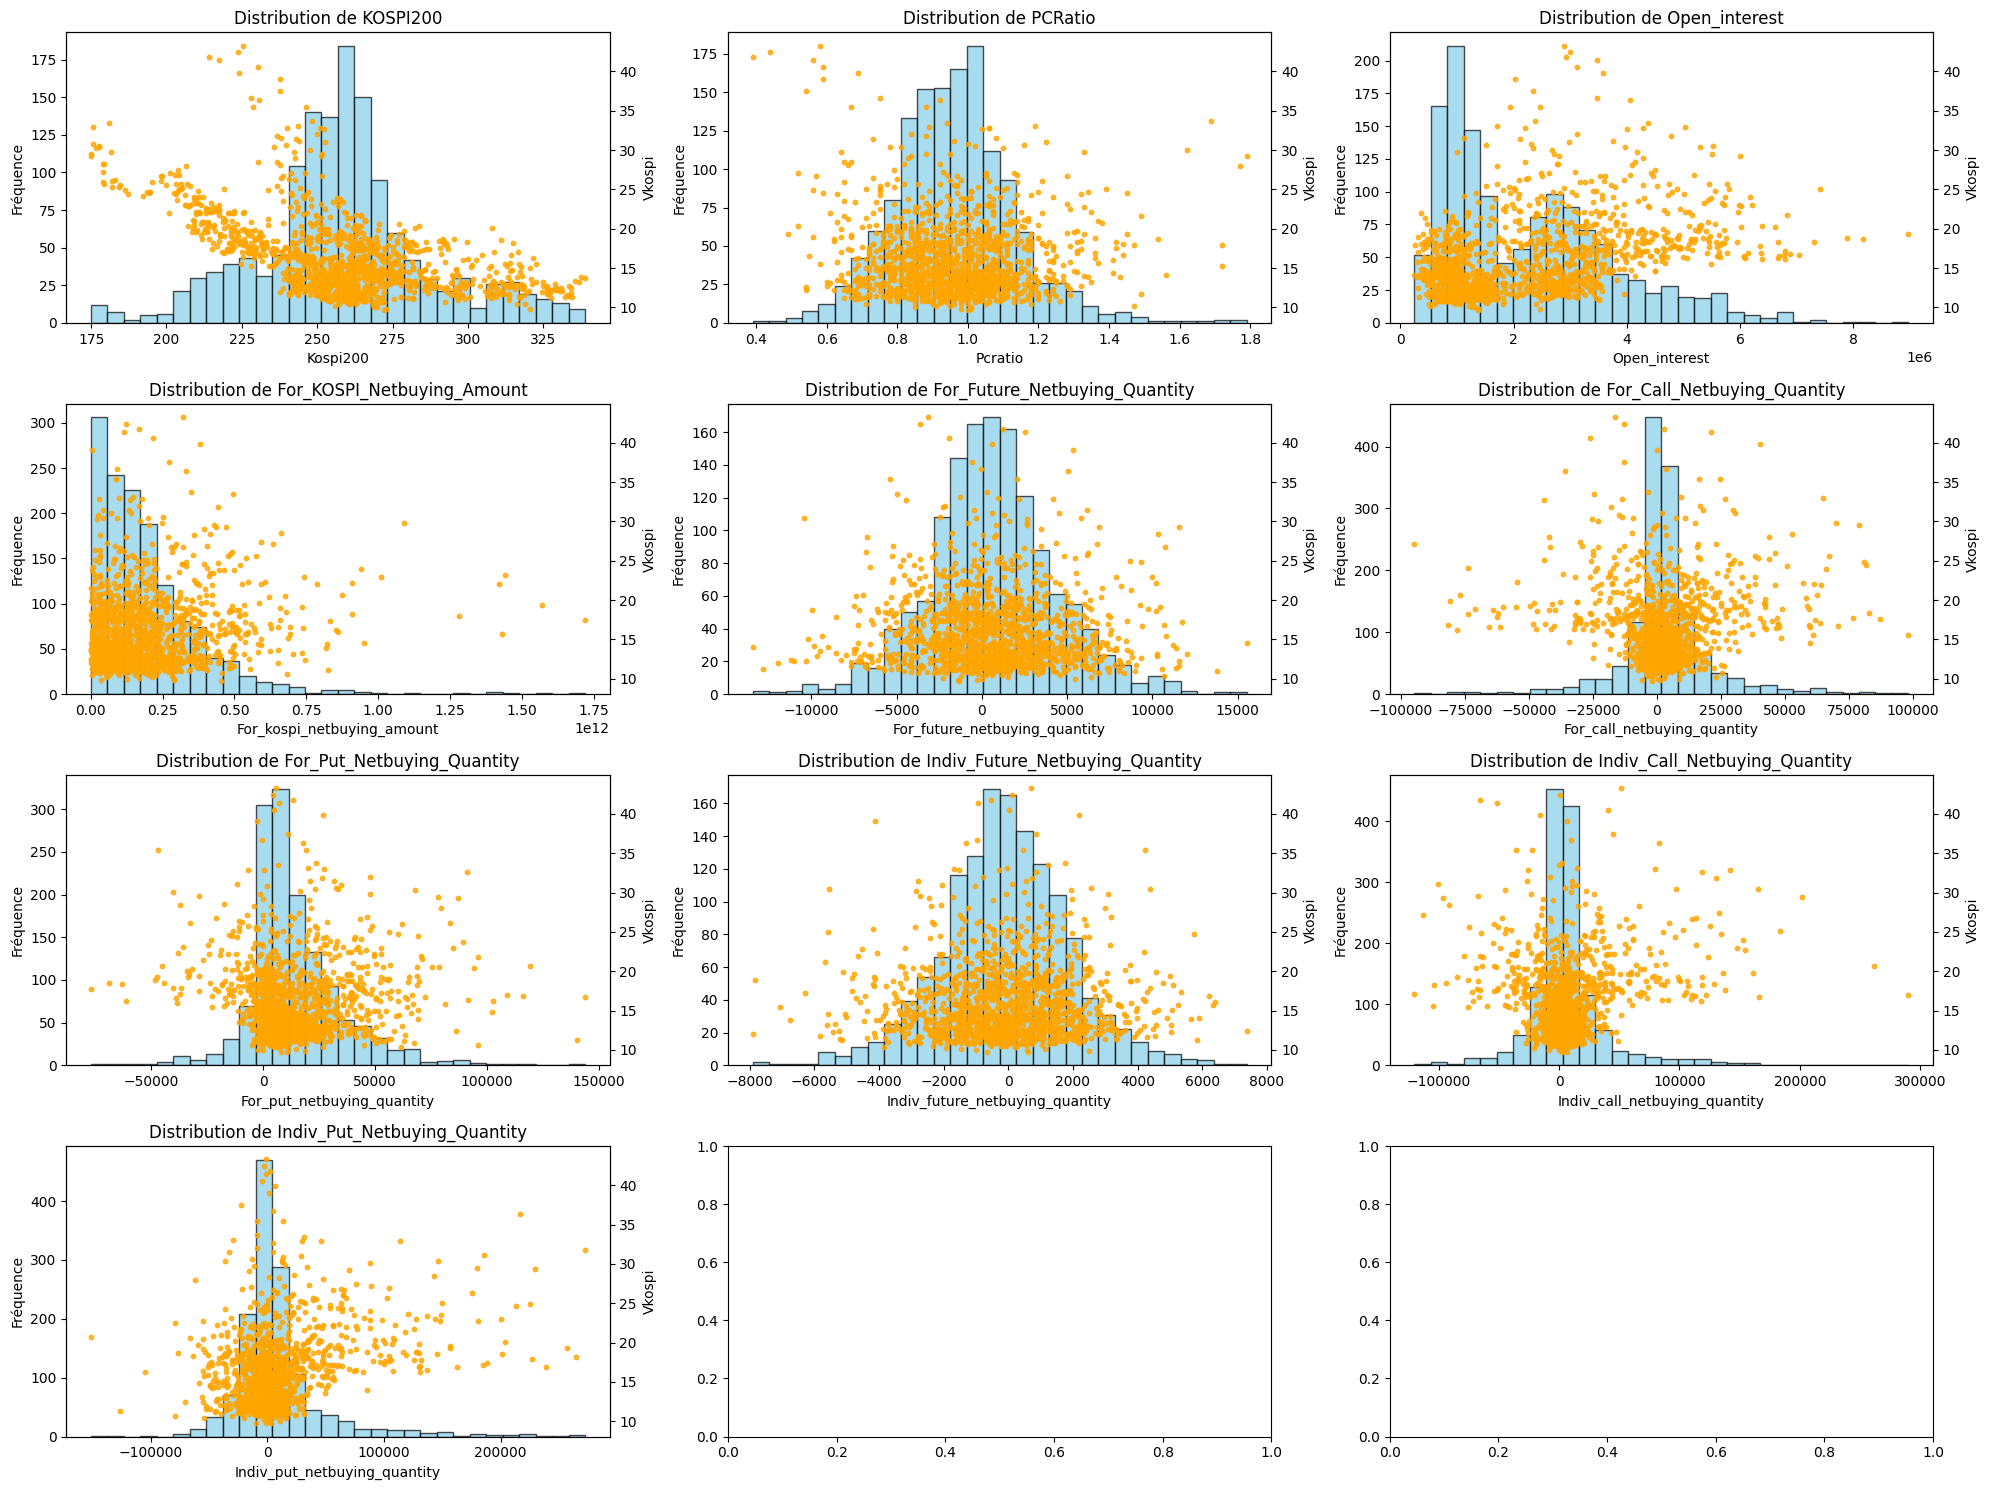

In [278]:
explore_columns_combined(df, columns_to_explore, "VKOSPI")

C'est beaucoup mieux ! On voit qu'on peut être encore plus sévère sur les limites de définition des outliers, mais on pourra ajuster le tir plus tard si on constate que nos métriques ne sont pas assez satisfaisantes. On pourra aussi revenir sur nos pas et être plus tolérants envers les outliers si jamais on constate que notre R2 est négatif. En effet, les outliers ne sont pas toujours des erreurs (c'est encore plus vrai dans des données financières comme le VKOSPI !), et en supprimant drastiquement ces valeurs, on risque d'effacer des tendances importantes, ce qui pourraît entrainer un R2 faible voire négatif.

On va maintenant traiter notre donnée catégorielle : "Day_of_a_week".

Pour étudier la distribution de cette donnée, on va visualiser un violin plot :

In [279]:
def make_violin_plot(column, figsize=(15, 8)):
    plt.figure(figsize=figsize)
    sns.violinplot(data=df, x="VKOSPI", y=column, inner=None)
    plt.title("Distribution of VKOSPI in function of %s" % column.capitalize())
    plt.show()

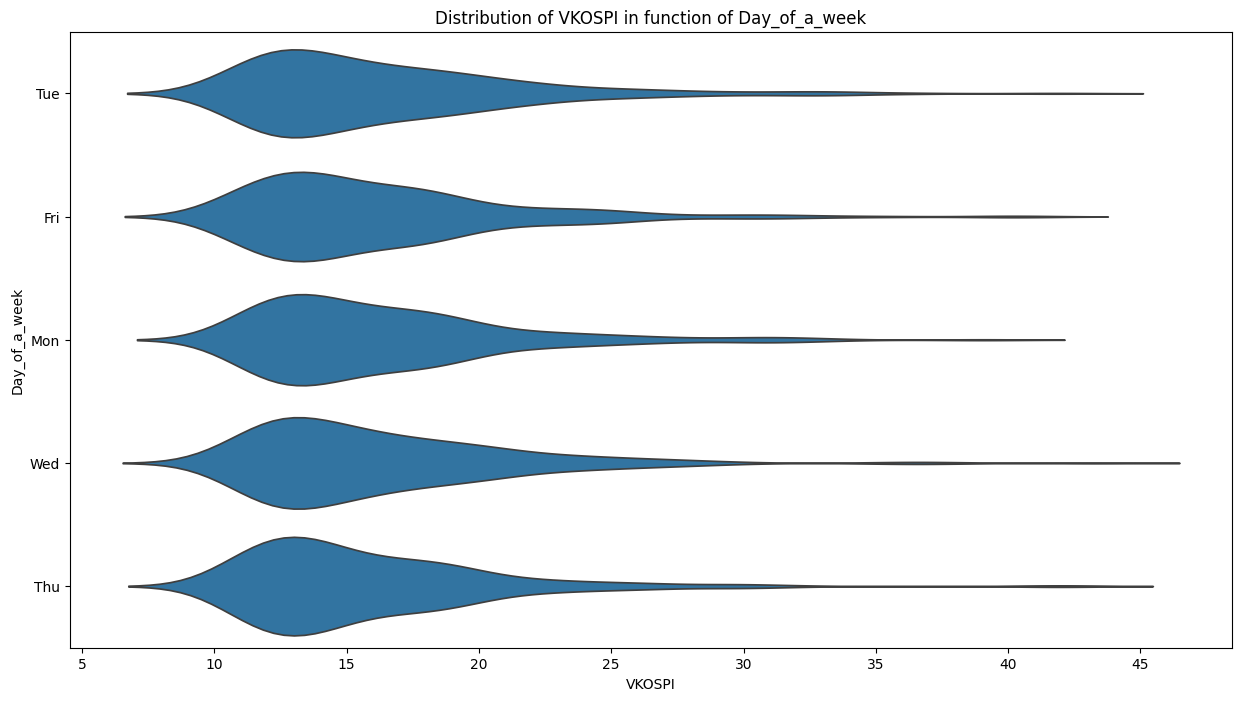

In [280]:
make_violin_plot("Day_of_a_week")

Il n'y a pas de grande tendance qui se dessine : nous ne pouvons pas exploiter cette donnée catégorielle directement. On va alors réaliser un One Hot Encoding.

In [281]:
df = pd.get_dummies(df, columns=["Day_of_a_week"])
df.head()

,Date,VKOSPI,KOSPI200,Open_interest,For_KOSPI_Netbuying_Amount,For_Future_Netbuying_Quantity,For_Call_Netbuying_Quantity,For_Put_Netbuying_Quantity,Indiv_Future_Netbuying_Quantity,Indiv_Call_Netbuying_Quantity,Indiv_Put_Netbuying_Quantity,PCRatio,Day_till_expiration,Day_of_a_week_Fri,Day_of_a_week_Mon,Day_of_a_week_Thu,Day_of_a_week_Tue,Day_of_a_week_Wed
0,2009-06-02,33.45,180.90,4377777,4.940000e+11,-4953,-24646,6581,1228,-466,31336,0.94,7,False,False,False,True,False
3,2009-06-05,32.95,175.75,5022921,9.842024e+10,969,64792,27196,-1688,79789,113935,0.89,4,True,False,False,False,False
4,2009-06-08,30.41,177.77,5293996,4.329179e+10,5797,10995,23123,-5534,97154,146244,0.81,3,False,True,False,False,False
5,2009-06-09,30.46,177.67,5520545,9.251058e+10,-10439,-9091,33572,4393,165009,12536,1.02,2,False,False,False,True,False
6,2009-06-10,29.31,174.91,5993901,4.340000e+11,11560,3077,86890,-2457,-96238,229505,0.84,1,False,False,False,False,True


On veut également déterminer les variables qui auront une importance (ou non) dans la prédiction. Pour cela, on peut utiliser une matrice de corrélation !

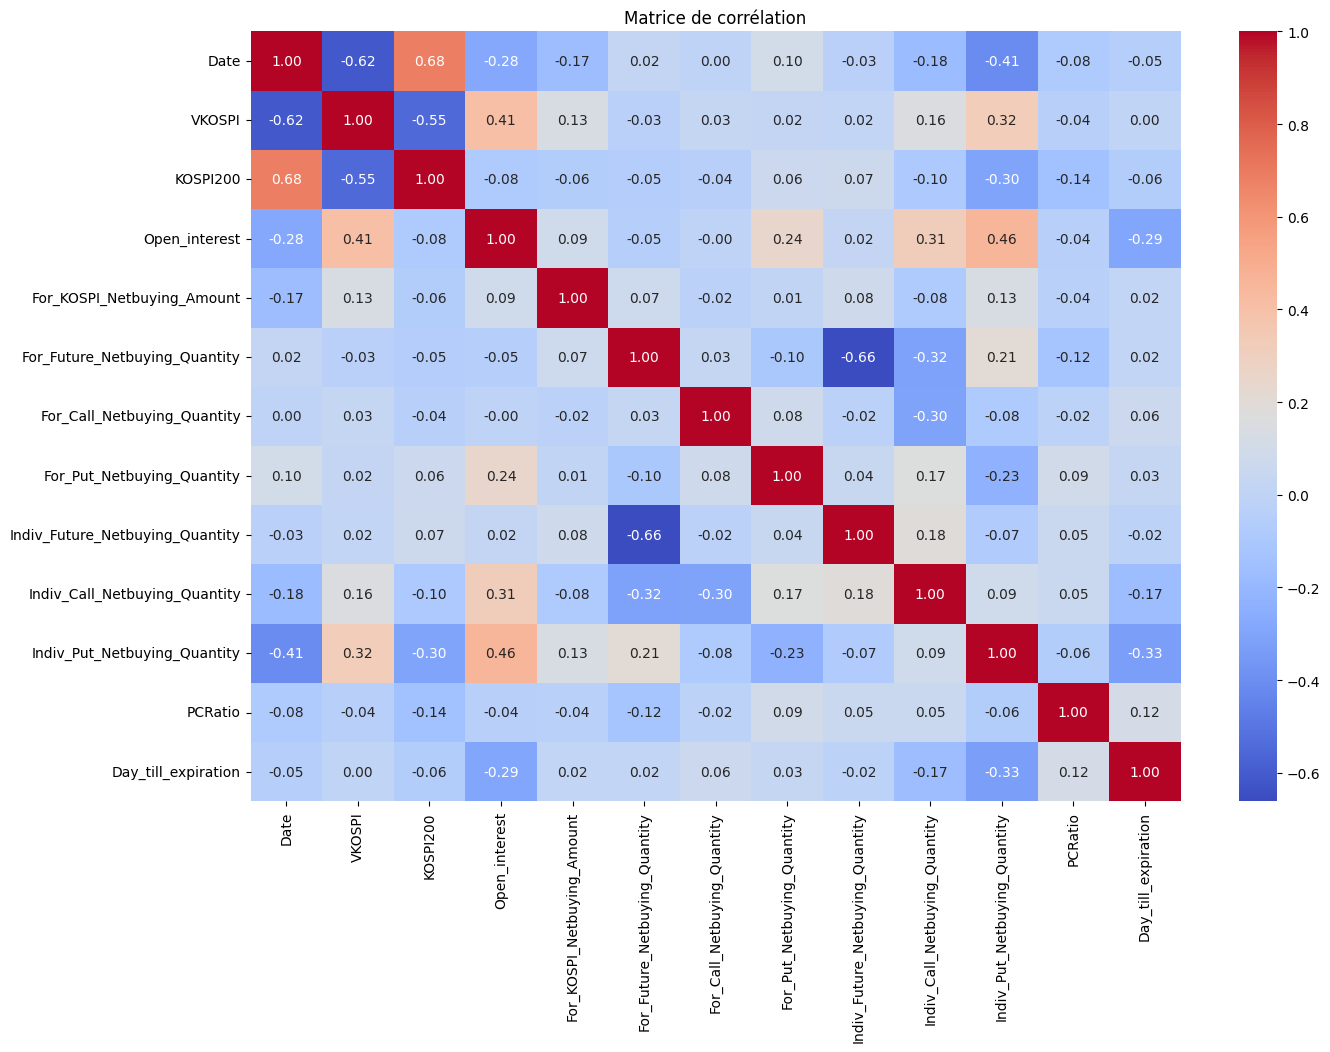

In [282]:
correlation_matrix = df.drop(columns=["Day_of_a_week_Fri", "Day_of_a_week_Mon", "Day_of_a_week_Thu", "Day_of_a_week_Tue", "Day_of_a_week_Wed"]).corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

On remarque une corrélation négative entre la VKOSPI et les variables "Date" et "KOSPI200", et des corrélations presque nulles avec d'autres variables. Pour le moment, nous allons garder ces variables, mais on garde dans un coin de notre tête qu'on peut les supprimer ou créer des features si nécessaire plus tard.

### **Modélisation**

On va maintenant séparer nos données en un ensemble d'entraînement et de test. Attention cependant car nos données sont indexées par le temps : toute coupure aléatoire est à bannir si on veut éviter de violer l'ordre temporel. D'après la consigne du projet, on va alors former un dataset de test composé des 20% dates les plus récentes.

In [283]:
# Trier les données par date
df_sorted = df.sort_values(by='Date').dropna()

# Séparer les 20% des données les plus récentes pour le test
split_index = int(len(df_sorted) * 0.8)
df_train = df_sorted.iloc[:split_index]
df_test = df_sorted.iloc[split_index:]

X_train = df_train.drop(columns=['VKOSPI', 'Date'])
y_train = df_train['VKOSPI']
X_test = df_test.drop(columns=['VKOSPI', 'Date'])
y_test = df_test['VKOSPI']

Nous décidons ensuite de standardiser nos données.

In [284]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

On va maintenant construire des modèles utilisant la régression linéaire, le Random Forest et Boosting (Gradient Boosting) pour prédire la valeur de VKOSPI.

On rappelle que la métrique utilisée sera la RMSE, et on souhaite également utiliser $R^2$, le coefficient de détermination.

In [285]:
def cross_validation_evaluation(model, X, y):
    rmse_scores = -cross_val_score(model, X, y, cv=10, scoring='neg_root_mean_squared_error')
    r2_scores = cross_val_score(model, X, y, cv=10, scoring='r2')
    print(f"\n{model.__class__.__name__} - Validation Croisée")
    print(f"Moyenne RMSE: {rmse_scores.mean():.2f} | Écart-type: {rmse_scores.std():.2f}")
    print(f"Moyenne R²: {r2_scores.mean():.2f} | Écart-type: {r2_scores.std():.2f}")

In [286]:
models = [Ridge(), RandomForestRegressor(), GradientBoostingRegressor()]
for model in models:
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{model.__class__.__name__}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.2f}")

    cross_validation_evaluation(model, X_train_scaled, y_train)


Ridge
RMSE: 2.79
R²: -0.80

Ridge - Validation Croisée
Moyenne RMSE: 3.85 | Écart-type: 2.32
Moyenne R²: -2.34 | Écart-type: 2.91

RandomForestRegressor
RMSE: 2.19
R²: -0.11

RandomForestRegressor - Validation Croisée
Moyenne RMSE: 4.06 | Écart-type: 2.26
Moyenne R²: -2.54 | Écart-type: 2.57

GradientBoostingRegressor
RMSE: 2.08
R²: 0.00

GradientBoostingRegressor - Validation Croisée
Moyenne RMSE: 3.88 | Écart-type: 2.21
Moyenne R²: -2.34 | Écart-type: 2.63


L'algorithme de Gradient Boosting s'est révélé être le plus performant. Nous allons donc nous appuyer sur ce modèle pour la suite du projet.

🎯 Objectif : atteindre une RMSE inférieure à 1.5 !
Pour y parvenir, nous allons exploiter les idées que nous avions mises de côté précédemment, tout en explorant de nouvelles pistes d'amélioration.

Commençons par rechercher les hyperparamètres optimaux du Gradient Boosting en utilisant la méthode de Random Search. *Une approche avec Grid Search avait été envisagée, mais elle a été interrompue après près de 400 minutes d'exécution d'une cellule...*

⚠️ Attention, vous êtes prévenus : lancer la cellule suivante entraînera plusieurs minutes d'attente.

💡 Note : L'exécution de cette cellule n'est pas nécessaire pour la suite du notebook, car nous utiliserons directement les hyperparamètres optimaux déjà déterminés par cette recherche.

In [287]:
"""# Hyperparamètres à optimiser
param_grid = {
    'n_estimators': [500, 1000, 1500, 2000],
    'learning_rate': [0.001, 0.005, 0.01, 0.05],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Optimisation avec RandomizedSearchCV
gb_model = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=param_grid,
    n_iter=30,
    cv=4,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='neg_root_mean_squared_error'
)

random_search.fit(X_train_scaled, y_train)

# Meilleur modèle et évaluation
best_gb_model = random_search.best_estimator_
y_pred_best_gb = best_gb_model.predict(X_test_scaled)

rmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))
r2_best_gb = r2_score(y_test, y_pred_best_gb)

print("Meilleurs paramètres:", random_search.best_params_)
print("RMSE optimisé:", rmse_best_gb)
print("R² optimisé:", r2_best_gb)"""

'# Hyperparamètres à optimiser\nparam_grid = {\n    \'n_estimators\': [500, 1000, 1500, 2000],\n    \'learning_rate\': [0.001, 0.005, 0.01, 0.05],\n    \'max_depth\': [3, 5, 7, 10],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'min_samples_split\': [2, 5, 10],\n    \'min_samples_leaf\': [1, 2, 4]\n}\n\n# Optimisation avec RandomizedSearchCV\ngb_model = GradientBoostingRegressor(random_state=42)\nrandom_search = RandomizedSearchCV(\n    estimator=gb_model,\n    param_distributions=param_grid,\n    n_iter=30,\n    cv=4,\n    verbose=2,\n    random_state=42,\n    n_jobs=-1,\n    scoring=\'neg_root_mean_squared_error\'\n)\n\nrandom_search.fit(X_train_scaled, y_train)\n\n# Meilleur modèle et évaluation\nbest_gb_model = random_search.best_estimator_\ny_pred_best_gb = best_gb_model.predict(X_test_scaled)\n\nrmse_best_gb = np.sqrt(mean_squared_error(y_test, y_pred_best_gb))\nr2_best_gb = r2_score(y_test, y_pred_best_gb)\n\nprint("Meilleurs paramètres:", random_search.best_params_)\nprint("RMSE o

On souhaite ensuite rajouter des features. Peut-être que nos données sont pauvres et ne permettent pas à notre modèle de bien apprendre.

In [288]:
df['KOSPI200_MA5'] = df['KOSPI200'].rolling(window=5).mean()
df['KOSPI200_MA10'] = df['KOSPI200'].rolling(window=10).mean()
df['KOSPI200_Volatility_5'] = df['KOSPI200'].rolling(window=5).std()
df['KOSPI200_Volatility_10'] = df['KOSPI200'].rolling(window=10).std()
df['Call_Put_Ratio'] = df['For_Call_Netbuying_Quantity'] / (df['For_Put_Netbuying_Quantity'] + 1)
df['Call_Put_Interaction'] = df['For_Call_Netbuying_Quantity'] * df['For_Put_Netbuying_Quantity']
df['KOSPI200_Return'] = df['KOSPI200'].pct_change()
df['MA5_MA10_Diff'] = df['KOSPI200_MA5'] - df['KOSPI200_MA10']

# Nouvelles variables basées sur les corrélations
df['Volatility_Diff'] = df['KOSPI200_Volatility_5'] - df['KOSPI200_Volatility_10']
df['Momentum'] = df['KOSPI200_Return'] * df['KOSPI200_MA5']
df['Interaction_Ratio'] = df['Call_Put_Interaction'] / (df['Call_Put_Ratio'] + 1)

# Nouvelles variables pour capturer les relations inverses
df['Inverse_Call_Put_Ratio'] = 1 / (df['Call_Put_Ratio'] + 1)
df['KOSPI200_Drawdown'] = df['KOSPI200'] / df['KOSPI200'].cummax() - 1
df['Inverse_Momentum'] = -df['KOSPI200_Return'] * df['KOSPI200_MA5']
df['Volatility_Ratio'] = df['KOSPI200_Volatility_5'] / (df['KOSPI200_Volatility_10'] + 1e-6)
df['Cum_Call_Put_Diff'] = df['For_Call_Netbuying_Quantity'].cumsum() - df['For_Put_Netbuying_Quantity'].cumsum()

# Ratio dynamique entre volatilité et rendement
df['Volatility_Return_Ratio'] = df['KOSPI200_Volatility_5'] / (df['KOSPI200_Return'].abs() + 1e-6)

Relançons le GradientBoosting une fois les features ajoutées, et avec les hyperparamètres trouvés plus haut.

In [289]:
df_sorted = df.sort_values(by='Date').dropna()
split_index = int(len(df_sorted) * 0.8)
df_train = df_sorted.iloc[:split_index]
df_test = df_sorted.iloc[split_index:]

X_train = df_train.drop(columns=['VKOSPI', 'Date'])
y_train = df_train['VKOSPI']
X_test = df_test.drop(columns=['VKOSPI', 'Date'])
y_test = df_test['VKOSPI']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = GradientBoostingRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=3,
    min_samples_leaf=2,
    min_samples_split= 10
)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\n{model.__class__.__name__}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


GradientBoostingRegressor
RMSE: 1.59
R²: 0.42


🏆 On s'approche du but !